#Colab GPU SetUp

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: GPU is not available.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


#Checking GPU Memory

In [ ]:
!nvidia-smi

Sat Sep 19 12:29:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#Importing required libraries

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

print("Libraries imported successfully.")

Libraries imported successfully.


#Mounting google drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


#Creating a folder

In [ ]:
BASE_DIR = "/content/drive/MyDrive/Emotion_Recognition_Thesis"

DATA_DIR = os.path.join(BASE_DIR, "datasets")
MODEL_DIR = os.path.join(BASE_DIR, "models")
RESULT_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Data directory:", DATA_DIR)
print("Model directory:", MODEL_DIR)
print("Results directory:", RESULT_DIR)

Base directory: /content/drive/MyDrive/Emotion_Recognition_Thesis
Data directory: /content/drive/MyDrive/Emotion_Recognition_Thesis/datasets
Model directory: /content/drive/MyDrive/Emotion_Recognition_Thesis/models
Results directory: /content/drive/MyDrive/Emotion_Recognition_Thesis/results


In [ ]:
!ls -lah "/content/drive/MyDrive"

total 5.3M
drwx------ 5 root root 4.0K Sep 19 12:30  .
drwx------ 5 root root 4.0K Sep 19 12:30  ..
-rw------- 1 root root 2.0M Nov 29  2020  189E1A05A3-ppl1.docx
drwx------ 2 root root 4.0K Dec  4  2023  AWS
drwx------ 2 root root 4.0K Aug 15 18:31 'Colab Notebooks'
drwx------ 5 root root 4.0K Aug 27 14:33  Emotion_Recognition_Thesis
-rw------- 1 root root 1.5M Dec 12  2017 'Getting started.pdf'
-rw------- 1 root root 1.6M Apr 24  2023  IMG_20230424_091928.jpg
-rw------- 1 root root 135K Mar 11  2025  photo_copy.pdf
-rw------- 1 root root  30K Apr 24  2023  Photo.jpg
-rw------- 1 root root 3.6K Aug 20  2020  python
-rw------- 1 root root 4.4K Aug 20  2020 'python '
-rw------- 1 root root  18K Apr 24  2023 'Signature .jpg'
-rw------- 1 root root  15K Apr 24  2023  Sign.jpg


In [ ]:
!find "/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets" -maxdepth 3 -type d

/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/neutral
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/surprise
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/disgust
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/fear
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/happy
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/sad
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/anger
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/contempt
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Train
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Train/neutral
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Train/sad
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Train/fear
/content/drive/MyDrive/Emotion_Re

In [ ]:
!find "/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets" -maxdepth 3 -type f | head -30

/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/labels.csv
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/neutral/ffhq_2311.png
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/neutral/ffhq_224.png
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/neutral/ffhq_990.png
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/neutral/ffhq_464.png
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/neutral/ffhq_643.png
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/neutral/ffhq_609.png
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/neutral/ffhq_838.png
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/neutral/ffhq_2344.png
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/neutral/ffhq_821.png
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/neutral/ffhq_93.png
/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets/Test/neutral/ffhq_48

#Exploratory Data Analysis

In [ ]:
import os

DATASET_DIR = "/content/drive/MyDrive/Emotion_Recognition_Thesis/datasets"

TRAIN_DIR = os.path.join(DATASET_DIR, "Train")
TEST_DIR = os.path.join(DATASET_DIR, "Test")

In [ ]:
print("Train folders:")
print(sorted(os.listdir(TRAIN_DIR)))

print("\nTest folders:")
print(sorted(os.listdir(TEST_DIR)))

Train folders:
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Test folders:
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


#Defining classes for emotions

In [ ]:
EMOTION_CLASSES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

NUM_CLASSES = len(EMOTION_CLASSES)

print("Number of emotion classes:", NUM_CLASSES)

for i, emotion in enumerate(EMOTION_CLASSES):
    print(i, "->", emotion)

Number of emotion classes: 8
0 -> anger
1 -> contempt
2 -> disgust
3 -> fear
4 -> happy
5 -> neutral
6 -> sad
7 -> surprise


#Counting images in each class

In [ ]:
from collections import OrderedDict

def count_images(folder):
    class_counts = OrderedDict()

    valid_extensions = (
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    )

    for emotion in EMOTION_CLASSES:
        class_folder = os.path.join(folder, emotion)

        files = [
            file for file in os.listdir(class_folder)
            if file.lower().endswith(valid_extensions)
        ]

        class_counts[emotion] = len(files)

    return class_counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("TRAIN")
for emotion, count in train_counts.items():
    print(f"{emotion:10s}: {count:,}")

print("\nTEST")
for emotion, count in test_counts.items():
    print(f"{emotion:10s}: {count:,}")

TRAIN
anger     : 1,500
contempt  : 1,559
disgust   : 1,229
fear      : 1,512
happy     : 2,340
neutral   : 2,758
sad       : 3,091
surprise  : 2,119

TEST
anger     : 1,718
contempt  : 1,312
disgust   : 1,248
fear      : 1,664
happy     : 2,704
neutral   : 2,368
sad       : 1,584
surprise  : 1,920


In [ ]:
total_train = sum(train_counts.values())
total_test = sum(test_counts.values())

print("\nTotal training images:", f"{total_train:,}")
print("Total test images:", f"{total_test:,}")
print("Total dataset images:", f"{total_train + total_test:,}")


Total training images: 16,108
Total test images: 14,518
Total dataset images: 30,626


#Creating a dataset-summary dataframe

In [ ]:
summary_df = pd.DataFrame({
    "Emotion": EMOTION_CLASSES,
    "Train": [train_counts[c] for c in EMOTION_CLASSES],
    "Test": [test_counts[c] for c in EMOTION_CLASSES]
})

summary_df["Total"] = (
    summary_df["Train"] +
    summary_df["Test"]
)

summary_df["Train_Percentage"] = (
    summary_df["Train"] /
    summary_df["Train"].sum() * 100
)

summary_df

,Emotion,Train,Test,Total,Train_Percentage
0,anger,1500,1718,3218,9.312143
1,contempt,1559,1312,2871,9.678421
2,disgust,1229,1248,2477,7.629749
3,fear,1512,1664,3176,9.386640
4,happy,2340,2704,5044,14.526943
5,neutral,2758,2368,5126,17.121927
6,sad,3091,1584,4675,19.189223
7,surprise,2119,1920,4039,13.154954


#Verifying pytorch

In [ ]:
from torchvision import datasets, transforms

inspection_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset_check = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=inspection_transform
)

test_dataset_check = datasets.ImageFolder(
    root=TEST_DIR,
    transform=inspection_transform
)

In [ ]:
print("Train classes:")
print(train_dataset_check.classes)

print("\nTrain class mapping:")
print(train_dataset_check.class_to_idx)

print("\nTest classes:")
print(test_dataset_check.classes)

print("\nTest class mapping:")
print(test_dataset_check.class_to_idx)

Train classes:
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Train class mapping:
{'anger': 0, 'contempt': 1, 'disgust': 2, 'fear': 3, 'happy': 4, 'neutral': 5, 'sad': 6, 'surprise': 7}

Test classes:
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Test class mapping:
{'anger': 0, 'contempt': 1, 'disgust': 2, 'fear': 3, 'happy': 4, 'neutral': 5, 'sad': 6, 'surprise': 7}


In [ ]:
assert (
    train_dataset_check.class_to_idx
    == test_dataset_check.class_to_idx
), "ERROR: Train/Test class mappings do not match."

print("✓ Train and Test class mappings are identical.")

✓ Train and Test class mappings are identical.


#Image size inspection

In [ ]:
import random
from PIL import Image
from collections import Counter

sample_size = min(1000, len(train_dataset_check.samples))

sample_paths = random.sample(
    train_dataset_check.samples,
    sample_size
)

image_sizes = []

for path, _ in sample_paths:
    try:
        with Image.open(path) as img:
            image_sizes.append(img.size)
    except Exception as e:
        print("Problem reading:", path, e)

print("Images inspected:", len(image_sizes))
print("Unique dimensions found:", len(set(image_sizes)))

print("\n10 most common dimensions:")
for size, count in Counter(image_sizes).most_common(10):
    print(size, ":", count)

Images inspected: 1000
Unique dimensions found: 1

10 most common dimensions:
(96, 96) : 1000


#Checking image color modes

In [ ]:
image_modes = []

for path, _ in sample_paths:
    try:
        with Image.open(path) as img:
            image_modes.append(img.mode)
    except:
        pass

print(Counter(image_modes))

Counter({'RGB': 1000})


#Checking for corrupted images

In [ ]:
from PIL import Image
from tqdm.auto import tqdm

def find_corrupted_images(root_dir):

    corrupted = []

    image_paths = []

    for root, _, files in os.walk(root_dir):
        for file in files:
            if file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".webp")
            ):
                image_paths.append(
                    os.path.join(root, file)
                )

    print("Checking:", len(image_paths), "images")

    for path in tqdm(image_paths):

        try:
            with Image.open(path) as img:
                img.verify()

        except Exception:
            corrupted.append(path)

    return corrupted

In [ ]:
corrupted_train = find_corrupted_images(TRAIN_DIR)

print("\nCorrupted training images:", len(corrupted_train))

Checking: 16108 images


  0%|          | 0/16108 [00:00<?, ?it/s]


Corrupted training images: 0


In [ ]:
corrupted_test = find_corrupted_images(TEST_DIR)

print("\nCorrupted test images:", len(corrupted_test))

Checking: 14518 images


  0%|          | 0/14518 [00:00<?, ?it/s]


Corrupted test images: 0


#Displaying sample images

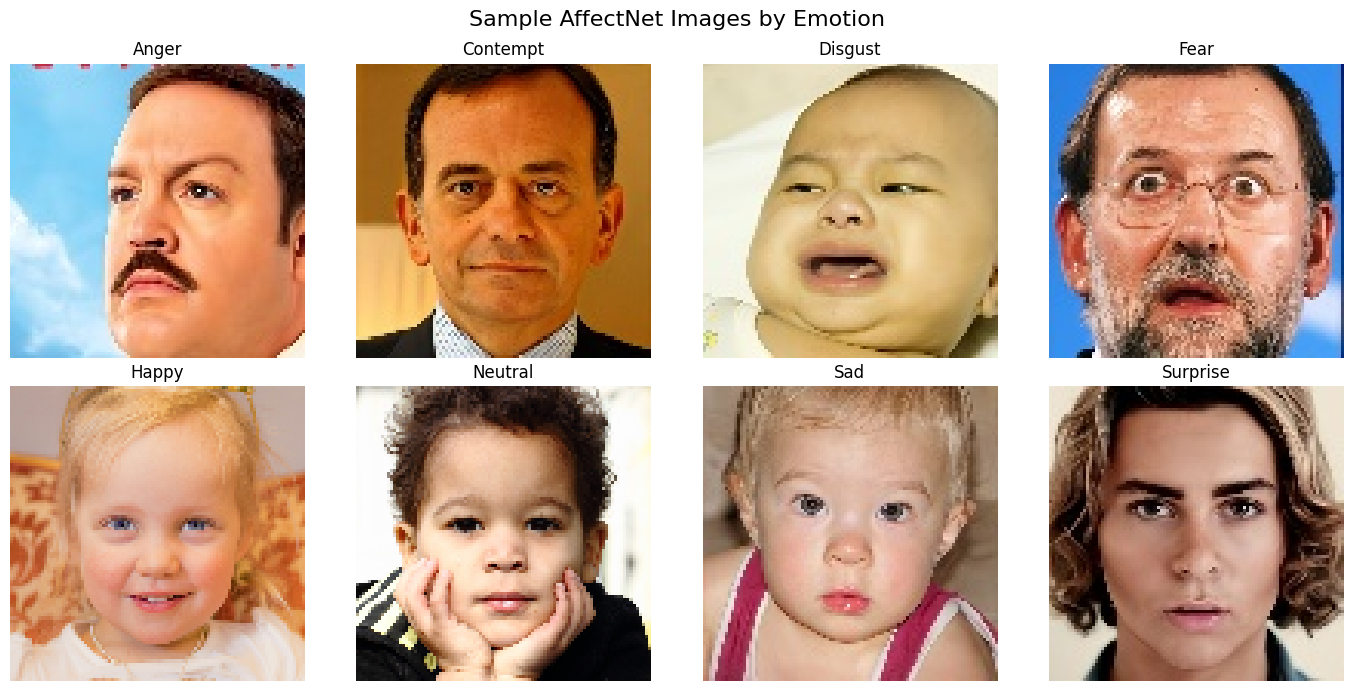

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7)
)

for ax, emotion in zip(
    axes.flatten(),
    EMOTION_CLASSES
):

    folder = os.path.join(
        TRAIN_DIR,
        emotion
    )

    image_name = random.choice(
        os.listdir(folder)
    )

    image_path = os.path.join(
        folder,
        image_name
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    ax.imshow(image)
    ax.set_title(
        emotion.capitalize(),
        fontsize=12
    )
    ax.axis("off")

plt.suptitle(
    "Sample AffectNet Images by Emotion",
    fontsize=16
)

plt.tight_layout()
plt.show()

#Saving data set summary

In [ ]:
DATASET_INFO_DIR = os.path.join(
    RESULT_DIR,
    "dataset_info"
)

os.makedirs(
    DATASET_INFO_DIR,
    exist_ok=True
)

summary_df.to_csv(
    os.path.join(
        DATASET_INFO_DIR,
        "affectnet_class_summary.csv"
    ),
    index=False
)

print(
    "Saved:",
    os.path.join(
        DATASET_INFO_DIR,
        "affectnet_class_summary.csv"
    )
)

Saved: /content/drive/MyDrive/Emotion_Recognition_Thesis/results/dataset_info/affectnet_class_summary.csv


In [ ]:
dataset_metadata = {
    "dataset": "AffectNet",
    "num_classes": NUM_CLASSES,
    "classes": ", ".join(EMOTION_CLASSES),
    "training_images": total_train,
    "test_images": total_test,
    "total_images": total_train + total_test,
    "corrupted_train_images": len(corrupted_train),
    "corrupted_test_images": len(corrupted_test)
}

metadata_df = pd.DataFrame(
    [dataset_metadata]
)

metadata_df.to_csv(
    os.path.join(
        DATASET_INFO_DIR,
        "affectnet_metadata.csv"
    ),
    index=False
)

metadata_df

,dataset,num_classes,classes,training_images,test_images,total_images,corrupted_train_images,corrupted_test_images
0,AffectNet,8,"anger, contempt, disgust, fear, happy, neutral...",16108,14518,30626,0,0


In [ ]:
train_distribution = pd.DataFrame({
    "Emotion": list(train_counts.keys()),
    "Count": list(train_counts.values())
})

train_distribution["Percentage"] = (
    train_distribution["Count"] /
    train_distribution["Count"].sum()
) * 100

train_distribution = train_distribution.sort_values(
    "Count",
    ascending=False
).reset_index(drop=True)

train_distribution

,Emotion,Count,Percentage
0,sad,3091,19.189223
1,neutral,2758,17.121927
2,happy,2340,14.526943
3,surprise,2119,13.154954
4,contempt,1559,9.678421
5,fear,1512,9.386640
6,anger,1500,9.312143
7,disgust,1229,7.629749


#Plotting class distribution

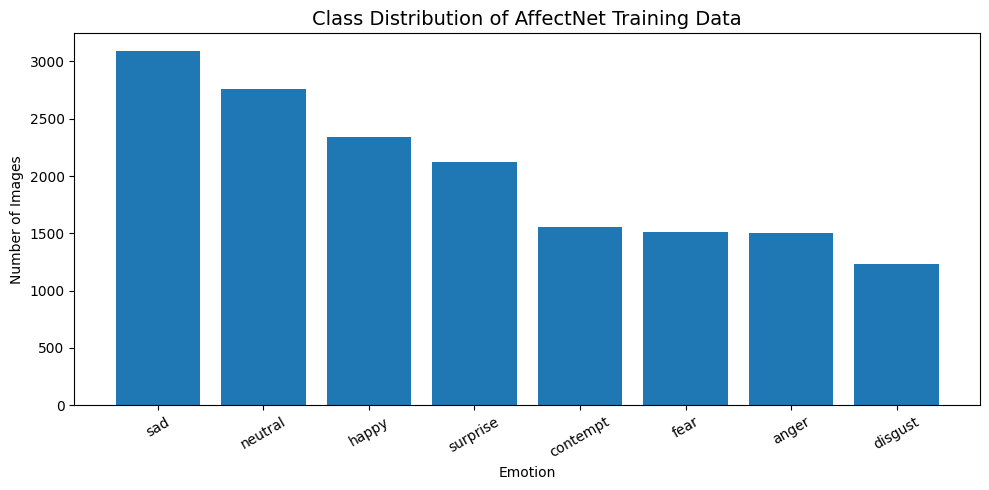

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    train_distribution["Emotion"],
    train_distribution["Count"]
)

plt.title(
    "Class Distribution of AffectNet Training Data",
    fontsize=14
)

plt.xlabel("Emotion")
plt.ylabel("Number of Images")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

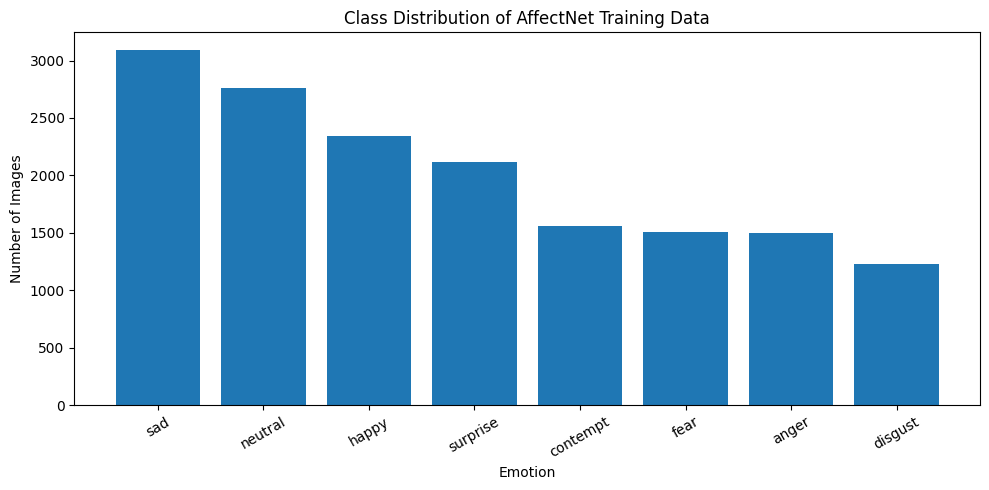

In [ ]:
EDA_PLOT_DIR = os.path.join(
    RESULT_DIR,
    "plots",
    "eda"
)

os.makedirs(
    EDA_PLOT_DIR,
    exist_ok=True
)

plt.figure(figsize=(10, 5))

plt.bar(
    train_distribution["Emotion"],
    train_distribution["Count"]
)

plt.title(
    "Class Distribution of AffectNet Training Data"
)

plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    os.path.join(
        EDA_PLOT_DIR,
        "affectnet_class_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Calculating imbalance ratio

In [ ]:
largest_class = train_distribution.iloc[0]
smallest_class = train_distribution.iloc[-1]

imbalance_ratio = (
    largest_class["Count"] /
    smallest_class["Count"]
)

print(
    "Largest class:",
    largest_class["Emotion"],
    largest_class["Count"]
)

print(
    "Smallest class:",
    smallest_class["Emotion"],
    smallest_class["Count"]
)

print(
    "Imbalance ratio:",
    round(imbalance_ratio, 2)
)

Largest class: sad 3091
Smallest class: disgust 1229
Imbalance ratio: 2.52


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
data_records = []

for emotion in EMOTION_CLASSES:

    class_folder = os.path.join(
        TRAIN_DIR,
        emotion
    )

    for filename in os.listdir(class_folder):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            data_records.append({
                "path": os.path.join(
                    class_folder,
                    filename
                ),
                "emotion": emotion
            })

train_full_df = pd.DataFrame(
    data_records
)

print(train_full_df.shape)

train_full_df.head()

(16108, 2)


,path,emotion
0,/content/drive/MyDrive/Emotion_Recognition_The...,anger
1,/content/drive/MyDrive/Emotion_Recognition_The...,anger
2,/content/drive/MyDrive/Emotion_Recognition_The...,anger
3,/content/drive/MyDrive/Emotion_Recognition_The...,anger
4,/content/drive/MyDrive/Emotion_Recognition_The...,anger


In [ ]:
class_to_idx = {
    emotion: idx
    for idx, emotion in enumerate(
        EMOTION_CLASSES
    )
}

idx_to_class = {
    idx: emotion
    for emotion, idx
    in class_to_idx.items()
}

train_full_df["label"] = (
    train_full_df["emotion"]
    .map(class_to_idx)
)

train_full_df.head()

,path,emotion,label
0,/content/drive/MyDrive/Emotion_Recognition_The...,anger,0
1,/content/drive/MyDrive/Emotion_Recognition_The...,anger,0
2,/content/drive/MyDrive/Emotion_Recognition_The...,anger,0
3,/content/drive/MyDrive/Emotion_Recognition_The...,anger,0
4,/content/drive/MyDrive/Emotion_Recognition_The...,anger,0


In [ ]:
train_df, val_df = train_test_split(
    train_full_df,
    test_size=0.15,
    random_state=42,
    stratify=train_full_df["label"]
)

#Splitting the data set

In [ ]:
print(
    "Training images:",
    len(train_df)
)

print(
    "Validation images:",
    len(val_df)
)

print(
    "Original test images:",
    total_test
)

Training images: 13691
Validation images: 2417
Original test images: 14518


#Verifying class distribution

In [ ]:
print("TRAIN")
print(
    train_df["emotion"]
    .value_counts()
    .sort_index()
)

print("\nVALIDATION")
print(
    val_df["emotion"]
    .value_counts()
    .sort_index()
)

TRAIN
emotion
anger       1275
contempt    1325
disgust     1045
fear        1285
happy       1989
neutral     2344
sad         2627
surprise    1801
Name: count, dtype: int64

VALIDATION
emotion
anger       225
contempt    234
disgust     184
fear        227
happy       351
neutral     414
sad         464
surprise    318
Name: count, dtype: int64


#Saving the splits

In [ ]:
SPLIT_DIR = os.path.join(
    RESULT_DIR,
    "dataset_splits"
)

os.makedirs(
    SPLIT_DIR,
    exist_ok=True
)

train_df.to_csv(
    os.path.join(
        SPLIT_DIR,
        "affectnet_train.csv"
    ),
    index=False
)

val_df.to_csv(
    os.path.join(
        SPLIT_DIR,
        "affectnet_validation.csv"
    ),
    index=False
)

print("Splits saved.")

Splits saved.


#Creating dataframe for original test set

In [ ]:
test_records = []

for emotion in EMOTION_CLASSES:

    class_folder = os.path.join(
        TEST_DIR,
        emotion
    )

    for filename in os.listdir(
        class_folder
    ):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            test_records.append({
                "path": os.path.join(
                    class_folder,
                    filename
                ),
                "emotion": emotion,
                "label": class_to_idx[emotion]
            })

test_df = pd.DataFrame(
    test_records
)

print(test_df.shape)

test_df.head()

(14518, 3)


,path,emotion,label
0,/content/drive/MyDrive/Emotion_Recognition_The...,anger,0
1,/content/drive/MyDrive/Emotion_Recognition_The...,anger,0
2,/content/drive/MyDrive/Emotion_Recognition_The...,anger,0
3,/content/drive/MyDrive/Emotion_Recognition_The...,anger,0
4,/content/drive/MyDrive/Emotion_Recognition_The...,anger,0


In [ ]:
test_df.to_csv(
    os.path.join(
        SPLIT_DIR,
        "affectnet_test.csv"
    ),
    index=False
)

#Defining preprocessing

In [ ]:
from torchvision import transforms

val_test_transform = transforms.Compose([
    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

#Training Augmentation

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

#Creating custom pyTorch dataset

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class FacialEmotionDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.transform = transform

    def __len__(self):

        return len(
            self.dataframe
        )

    def __getitem__(
        self,
        index
    ):

        row = (
            self.dataframe
            .iloc[index]
        )

        image = (
            Image
            .open(row["path"])
            .convert("RGB")
        )

        label = int(
            row["label"]
        )

        if self.transform:

            image = self.transform(
                image
            )

        return image, label

#Creating Datasets

In [ ]:
train_dataset = FacialEmotionDataset(
    train_df,
    transform=train_transform
)

val_dataset = FacialEmotionDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = FacialEmotionDataset(
    test_df,
    transform=val_test_transform
)

In [ ]:
print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

print(
    "Test:",
    len(test_dataset)
)

Train: 13691
Validation: 2417
Test: 14518


#Inspect tensor shape

In [ ]:
image, label = train_dataset[0]

print(
    "Image tensor shape:",
    image.shape
)

print(
    "Label:",
    label
)

print(
    "Emotion:",
    idx_to_class[label]
)

Image tensor shape: torch.Size([3, 224, 224])
Label: 5
Emotion: neutral


#Creating Dataloaders

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

#Testing one batch

In [ ]:
images, labels = next(
    iter(train_loader)
)

print(
    "Batch image shape:",
    images.shape
)

print(
    "Batch label shape:",
    labels.shape
)

print(
    "First labels:",
    labels[:10]
)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
First labels: tensor([6, 2, 7, 5, 1, 4, 4, 2, 1, 7])


#GPU Transfer test

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

images = images.to(device)
labels = labels.to(device)

print(
    "Images device:",
    images.device
)

print(
    "Labels device:",
    labels.device
)

Images device: cuda:0
Labels device: cuda:0


**KEY POINTS:** In this notebook I have done the following things


*   Dataset Loading
*   EDA and Class distribution
*   Train/Validation/Test split
*   Image Preprocessing
*   Data Augmentation

